# Congressional Trading Risk Intelligence
## 03 — Disclosure Compliance Analysis

This notebook examines the time between a reported securities transaction and its public disclosure.

The legal/compliance question is whether the available dates suggest that a Periodic Transaction Report (PTR) may have been filed outside the statutory timing window.

### Legal framework used

For reportable securities transactions over $1,000, congressional PTR rules generally require filing by the **earlier** of:

1. **30 days after the filer receives notice of the transaction**, or
2. **45 days after the transaction date**.

Because this dataset contains the **transaction date** and **disclosure date**, but not the date on which the filer received notice, this analysis can directly test only the **45-day outer limit**.

Accordingly, records with a calculated lag greater than 45 days are labelled **`Potentially Late — Date Review Needed`**, not as violations.

### Official guidance consulted
- U.S. House Committee on Ethics — Financial Disclosure / PTR guidance
- U.S. Senate Select Committee on Ethics — Financial Disclosure / PTR guidance

> **Important:** This notebook does not determine that any lawmaker violated the STOCK Act or another ethics rule. Filing extensions, amendments, corrected dates, exempt transactions, source-data errors, or other factual circumstances may affect the legal analysis.


## 1. Import libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


## 2. Load the cleaned dataset

In [2]:
DATA_PATH = Path("../data/processed/us_congress_trades_clean.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["disclosure_date", "transaction_date"]
)

print(f"Rows: {len(df):,}")
print(f"Unique lawmakers: {df['representative'].nunique():,}")
print(f"Transaction-date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
df.head()


Rows: 16,616
Unique lawmakers: 196
Transaction-date range: 2012-06-19 to 2023-12-22


,disclosure_year,disclosure_date,transaction_date,owner,ticker,asset_description,type,amount,representative,district,state,ptr_link,cap_gains_over_200_usd,industry,sector,party,amount_min,amount_max,amount_midpoint,disclosure_lag_days
0,2021,2021-10-04,2021-09-27,joint,BP,BP plc,purchase,"$1,001 - $15,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Integrated oil Companies,Energy,Republican,1001.0,15000.0,8000.5,7.0
1,2021,2021-10-04,2021-09-13,joint,XOM,Exxon Mobil Corporation,purchase,"$1,001 - $15,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Integrated oil Companies,Energy,Republican,1001.0,15000.0,8000.5,21.0
2,2021,2021-10-04,2021-09-10,joint,ILPT,Industrial Logistics Properties Trust - Common Shares of Beneficial Interest,purchase,"$15,001 - $50,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Real Estate Investment Trusts,Real Estate,Republican,15001.0,50000.0,32500.5,24.0
3,2021,2021-10-04,2021-09-28,joint,PM,Phillip Morris International Inc,purchase,"$15,001 - $50,000",Virginia Foxx,NC05,NC,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019557.pdf,False,Farming/Seeds/Milling,Consumer Non-Durables,Republican,15001.0,50000.0,32500.5,6.0
4,2021,2021-10-04,2021-09-17,self,BLK,BlackRock Inc,sale_partial,"$1,001 - $15,000",Alan S. Lowenthal,CA47,CA,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019570.pdf,False,Investment Bankers/Brokers/Service,Finance,Democrat,1001.0,15000.0,8000.5,17.0


## 3. Recalculate disclosure lag

`disclosure_lag_days` is the number of calendar days between the transaction date and the disclosure date.

A negative value is logically inconsistent for an ordinary post-transaction disclosure and is therefore treated as a **data-quality review item**, not a compliance conclusion.


In [3]:
df["disclosure_lag_days"] = (
    df["disclosure_date"] - df["transaction_date"]
).dt.days

df[
    [
        "representative",
        "transaction_date",
        "disclosure_date",
        "disclosure_lag_days"
    ]
].head(10)


,representative,transaction_date,disclosure_date,disclosure_lag_days
0,Virginia Foxx,2021-09-27,2021-10-04,7.0
1,Virginia Foxx,2021-09-13,2021-10-04,21.0
2,Virginia Foxx,2021-09-10,2021-10-04,24.0
3,Virginia Foxx,2021-09-28,2021-10-04,6.0
4,Alan S. Lowenthal,2021-09-17,2021-10-04,17.0
5,Aston Donald McEachin,2021-12-01,2021-12-01,0.0
6,Austin Scott,2021-11-30,2021-12-01,1.0
7,Thomas Suozzi,2021-11-18,2021-12-01,13.0
8,Thomas Suozzi,2021-11-18,2021-12-01,13.0
9,Thomas Suozzi,2021-11-24,2021-12-01,7.0


## 4. Validate timing data

In [4]:
timing_quality = pd.DataFrame({
    "Metric": [
        "Total records",
        "Missing transaction dates",
        "Missing disclosure dates",
        "Missing calculated lags",
        "Negative disclosure lags",
        "Non-negative disclosure lags"
    ],
    "Count": [
        len(df),
        df["transaction_date"].isna().sum(),
        df["disclosure_date"].isna().sum(),
        df["disclosure_lag_days"].isna().sum(),
        (df["disclosure_lag_days"] < 0).sum(),
        (df["disclosure_lag_days"] >= 0).sum()
    ]
})

timing_quality


,Metric,Count
0,Total records,16616
1,Missing transaction dates,12
2,Missing disclosure dates,0
3,Missing calculated lags,12
4,Negative disclosure lags,15
5,Non-negative disclosure lags,16589


## 5. Describe reporting delay

The summary below excludes negative lags from the main descriptive statistics because those records require data-quality review.


In [5]:
valid_timing = df[df["disclosure_lag_days"] >= 0].copy()

valid_timing["disclosure_lag_days"].describe()


count    16589.000000
mean        57.424920
std        123.325525
min          0.000000
25%         17.000000
50%         28.000000
75%         38.000000
max       3355.000000
Name: disclosure_lag_days, dtype: float64

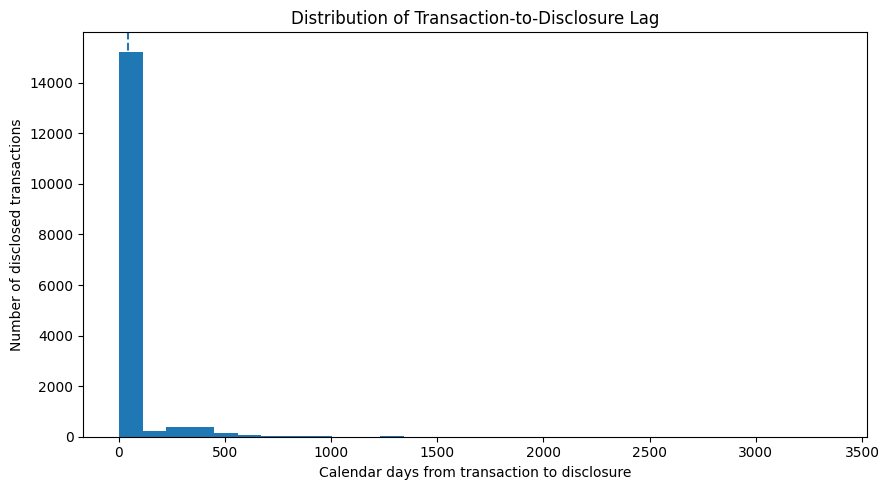

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(valid_timing["disclosure_lag_days"], bins=30)
plt.axvline(45, linestyle="--")
plt.title("Distribution of Transaction-to-Disclosure Lag")
plt.xlabel("Calendar days from transaction to disclosure")
plt.ylabel("Number of disclosed transactions")
plt.tight_layout()
plt.show()


The dashed line marks the **45-day outer limit** used for screening. It is not a finding of liability.


## 6. Create a compliance-screening flag

In [7]:
def timing_status(row):
    lag = row["disclosure_lag_days"]

    if pd.isna(lag):
        return "Insufficient Date Data"
    if lag < 0:
        return "Data Quality Review"
    if lag <= 45:
        return "Within 45-Day Outer Limit"
    return "Potentially Late — Date Review Needed"

df["timing_status"] = df.apply(timing_status, axis=1)

status_counts = (
    df["timing_status"]
    .value_counts()
    .rename_axis("Timing_Status")
    .reset_index(name="Count")
)

status_counts["Share_Percent"] = (
    status_counts["Count"] / len(df) * 100
).round(1)

status_counts


,Timing_Status,Count,Share_Percent
0,Within 45-Day Outer Limit,13983,84.2
1,Potentially Late — Date Review Needed,2606,15.7
2,Data Quality Review,15,0.1
3,Insufficient Date Data,12,0.1


### Why “potentially late”?

The dataset does not contain the filer-notification date needed to test the separate 30-day rule. It also may not capture amendments, corrections, exemptions, or other context.

Therefore, a lag greater than 45 days is best treated as a **screening signal for further review**, not a definitive legal conclusion.


## 7. Potentially late records by lawmaker

In [8]:
potentially_late = df[
    df["timing_status"] == "Potentially Late — Date Review Needed"
].copy()

late_by_lawmaker = (
    potentially_late.groupby("representative")
    .agg(
        Potentially_Late_Transactions=("representative", "size"),
        Median_Lag_Days=("disclosure_lag_days", "median"),
        Maximum_Lag_Days=("disclosure_lag_days", "max")
    )
    .reset_index()
    .sort_values(
        ["Potentially_Late_Transactions", "Maximum_Lag_Days"],
        ascending=[False, False]
    )
)

late_by_lawmaker.head(15)


,representative,Potentially_Late_Transactions,Median_Lag_Days,Maximum_Lag_Days
30,Donna Shalala,558,348.0,477.0
102,Susie Lee,180,61.5,317.0
77,Michael T. McCaul,172,52.0,70.0
18,Cynthia Axne,124,578.0,994.0
106,Tom Malinowski,95,449.0,3355.0
17,Chris Jacobs,85,59.0,315.0
65,Kurt Schrader,79,55.0,90.0
60,Katherine M. Clark,75,53.0,408.0
7,Blake Moore,71,135.0,178.0
71,Marie Newman,67,65.0,97.0


### Interpretation caution

A lawmaker appearing frequently in this table may simply have more transactions in the dataset. Raw counts should therefore be considered together with that lawmaker's total disclosed activity.


## 8. Normalize by each lawmaker's trading volume

In [9]:
all_by_lawmaker = (
    df.groupby("representative")
    .size()
    .rename("Total_Transactions")
    .reset_index()
)

late_rate = late_by_lawmaker.merge(
    all_by_lawmaker,
    on="representative",
    how="left"
)

late_rate["Potentially_Late_Rate_Percent"] = (
    late_rate["Potentially_Late_Transactions"] /
    late_rate["Total_Transactions"] * 100
).round(1)

late_rate.sort_values(
    ["Potentially_Late_Rate_Percent", "Potentially_Late_Transactions"],
    ascending=[False, False]
).head(15)


,representative,Potentially_Late_Transactions,Median_Lag_Days,Maximum_Lag_Days,Total_Transactions,Potentially_Late_Rate_Percent
46,Sean Patrick Maloney,8,280.0,280.0,8,100.0
48,Harley E. Rouda,7,358.0,512.0,7,100.0
52,Mary Gay Scanlon,6,546.0,557.0,6,100.0
57,Linda T. Sanchez,5,569.0,569.0,5,100.0
62,Stephen F. Lynch,4,129.0,489.0,4,100.0
76,Brian Higgins,3,341.0,341.0,3,100.0
80,Steve Chabot,2,446.0,446.0,2,100.0
86,John P. Sarbanes,2,325.5,334.0,2,100.0
90,Jamie Raskin,2,179.0,238.0,2,100.0
96,Teresa Leger Fernandez,1,686.0,686.0,1,100.0


## 9. Apply a minimum-volume threshold for comparisons

Rates based on only one or two transactions can be misleading. The table below limits the comparison to lawmakers with at least **10 transactions** in the cleaned dataset.


In [10]:
volume_threshold = 10

comparison = late_rate[
    late_rate["Total_Transactions"] >= volume_threshold
].copy()

comparison = comparison.sort_values(
    ["Potentially_Late_Rate_Percent", "Potentially_Late_Transactions"],
    ascending=[False, False]
)

comparison.head(15)


,representative,Potentially_Late_Transactions,Median_Lag_Days,Maximum_Lag_Days,Total_Transactions,Potentially_Late_Rate_Percent
0,Donna Shalala,558,348.0,477.0,566,98.6
22,David Madison Cawthorn,28,117.0,331.0,31,90.3
16,David P. Joyce,42,420.5,567.0,47,89.4
12,Sara Jacobs,51,49.0,60.0,64,79.7
4,Tom Malinowski,95,449.0,3355.0,125,76.0
8,Blake Moore,71,135.0,178.0,99,71.7
42,Daniel Meuser,10,434.0,434.0,14,71.4
36,August Lee Pfluger,12,125.0,196.0,17,70.6
49,Lloyd K. Smucker,7,102.0,177.0,10,70.0
3,Cynthia Axne,124,578.0,994.0,181,68.5


## 10. Potentially late disclosures over time

In [11]:
late_over_time = (
    potentially_late.assign(
        Transaction_Month=potentially_late["transaction_date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("Transaction_Month")
    .size()
    .reset_index(name="Potentially_Late_Count")
)

late_over_time.tail(12)


,Transaction_Month,Potentially_Late_Count
49,2022-04-01,5
50,2022-05-01,1
51,2022-06-01,5
52,2022-07-01,44
53,2022-08-01,17
54,2022-09-01,9
55,2022-10-01,6
56,2022-11-01,2
57,2022-12-01,9
58,2023-01-01,8


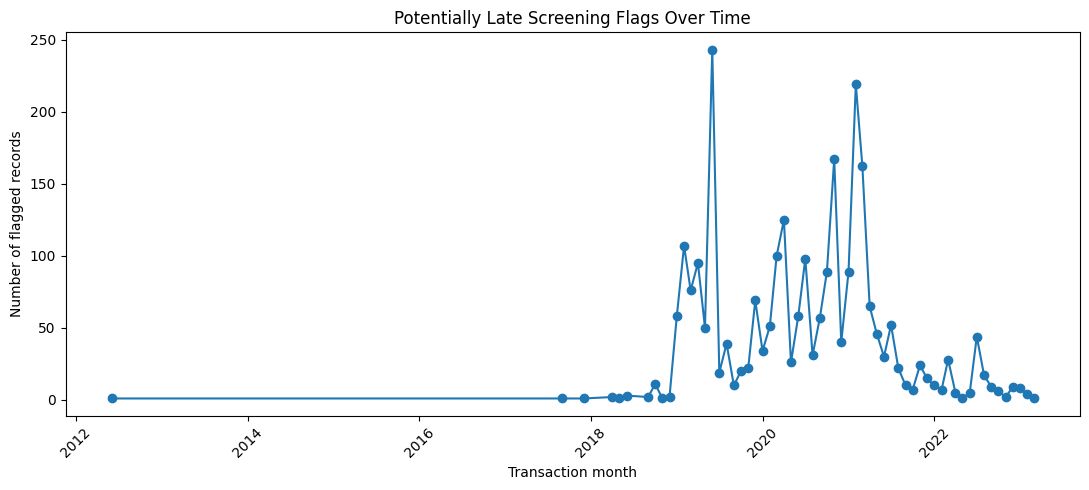

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(
    late_over_time["Transaction_Month"],
    late_over_time["Potentially_Late_Count"],
    marker="o"
)
plt.title("Potentially Late Screening Flags Over Time")
plt.xlabel("Transaction month")
plt.ylabel("Number of flagged records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Transaction types among flagged records

In [13]:
late_transaction_types = (
    potentially_late["type"]
    .value_counts()
    .rename_axis("Transaction_Type")
    .reset_index(name="Potentially_Late_Count")
)

late_transaction_types


,Transaction_Type,Potentially_Late_Count
0,purchase,1250
1,sale_full,982
2,sale_partial,331
3,exchange,43


## 12. Sectors represented among flagged records

In [14]:
late_sectors = (
    potentially_late["sector"]
    .value_counts()
    .rename_axis("Sector")
    .reset_index(name="Potentially_Late_Count")
)

late_sectors.head(15)


,Sector,Potentially_Late_Count
0,Technology,349
1,Health Care,270
2,Finance,229
3,Consumer Services,220
4,Consumer Discretionary,148
5,Energy,103
6,Capital Goods,92
7,Consumer Non-Durables,80
8,Industrials,69
9,Public Utilities,68


## 13. Review the longest calculated lags

In [15]:
longest_lags = (
    potentially_late[
        [
            "representative",
            "ticker",
            "asset_description",
            "type",
            "amount",
            "transaction_date",
            "disclosure_date",
            "disclosure_lag_days",
            "ptr_link"
        ]
    ]
    .sort_values("disclosure_lag_days", ascending=False)
)

longest_lags.head(20)


,representative,ticker,asset_description,type,amount,transaction_date,disclosure_date,disclosure_lag_days,ptr_link
11230,Tom Malinowski,BLFSD,BioLife Solutions Inc,purchase,"$1,001 - $15,000",2012-06-19,2021-08-26,3355.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2021/20019374.pdf
12082,Thomas Suozzi,SUP,Superior Industries International Inc Common Stock,purchase,"$1,001 - $15,000",2017-09-05,2022-03-03,1640.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12063,Thomas Suozzi,CAT,Caterpillar Inc,purchase,"$1,001 - $15,000",2017-12-06,2022-03-03,1548.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12062,Thomas Suozzi,BA,Boeing Company,purchase,"$15,001 - $50,000",2018-04-17,2022-03-03,1416.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12068,Thomas Suozzi,CTRL,Control4 Corporation,purchase,"$1,001 - $15,000",2018-04-30,2022-03-03,1403.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12079,Thomas Suozzi,GE,General Electric Company,sale_full,"$1,001 - $15,000",2018-05-08,2022-03-03,1395.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12081,Thomas Suozzi,IBM,International Business Machines Corporation,sale_full,"$1,001 - $15,000",2018-06-27,2022-03-03,1345.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12083,Thomas Suozzi,VZ,Verizon Communications Inc,purchase,"$1,001 - $15,000",2018-06-27,2022-03-03,1345.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12069,Thomas Suozzi,CRTL,Control4 Corporation,purchase,"$1,001 - $15,000",2018-06-27,2022-03-03,1345.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf
12080,Thomas Suozzi,INTC,Intel Corporation,purchase,"$15,001 - $50,000",2018-10-01,2022-03-03,1249.0,https://disclosures-clerk.house.gov/public_disc/ptr-pdfs/2022/20020552.pdf


The `ptr_link` field is retained so that an analyst can return to the underlying disclosure document before drawing a legal conclusion. This is an important human-review step in compliance analytics.


## 14. Compact compliance-screening summary

In [16]:
summary = pd.DataFrame({
    "Metric": [
        "Cleaned transactions",
        "Valid non-negative timing records",
        "Median disclosure lag (days)",
        "Records within 45-day outer limit",
        "Records over 45 days",
        "Negative-lag data-quality records",
        "Lawmakers with at least one >45-day flag"
    ],
    "Value": [
        len(df),
        (df["disclosure_lag_days"] >= 0).sum(),
        valid_timing["disclosure_lag_days"].median(),
        ((df["disclosure_lag_days"] >= 0) & (df["disclosure_lag_days"] <= 45)).sum(),
        (df["disclosure_lag_days"] > 45).sum(),
        (df["disclosure_lag_days"] < 0).sum(),
        potentially_late["representative"].nunique()
    ]
})

summary


,Metric,Value
0,Cleaned transactions,16616.0
1,Valid non-negative timing records,16589.0
2,Median disclosure lag (days),28.0
3,Records within 45-day outer limit,13983.0
4,Records over 45 days,2606.0
5,Negative-lag data-quality records,15.0
6,Lawmakers with at least one >45-day flag,114.0


## 15. Export screening results

In [17]:
OUTPUT_PATH = Path("../data/processed/congressional_disclosure_timing_screen.csv")

export_columns = [
    "representative",
    "party",
    "state",
    "ticker",
    "asset_description",
    "type",
    "amount",
    "transaction_date",
    "disclosure_date",
    "disclosure_lag_days",
    "timing_status",
    "ptr_link"
]

df[export_columns].to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")


Saved: ../data/processed/congressional_disclosure_timing_screen.csv


## Compliance-analysis conclusions

This notebook converts public financial-disclosure dates into a structured **compliance-screening workflow**.

### What the analysis can say
- how long the dataset indicates transactions took to be disclosed;
- which records exceed the 45-day outer-limit screening threshold;
- which records contain timing inconsistencies;
- which lawmakers have higher or lower screening-flag rates within this dataset; and
- which source disclosure documents warrant further review.

### What the analysis cannot say
- when the filer first received notice of the transaction;
- whether a particular transaction was legally reportable;
- whether an amendment or correction explains the recorded dates;
- whether a filer had a legally relevant exception or other factual context; or
- whether any person violated the STOCK Act or congressional ethics rules.

### Portfolio takeaway

This notebook demonstrates a core legal-tech skill: translating a legal rule into a **transparent, auditable data-screening control** while preserving human legal review and avoiding unsupported conclusions.

### Next possible notebook

**04 — Ethics Risk Intelligence Model**

A future model could combine disclosure delay, transaction frequency, estimated transaction magnitude, and concentration measures into an explainable screening score. Any such score should remain a review-prioritization tool rather than a determination of misconduct.
